In [4]:
# pip install pandas

In [5]:
import pandas as pd
df = pd.read_csv("delivery_time.csv")
df.head()

,distance_km,delivery_time_min
0,7.5,34
1,4.6,25
2,8.3,33
3,6.9,31
4,1.6,15


In [7]:
# pip install matplotlib

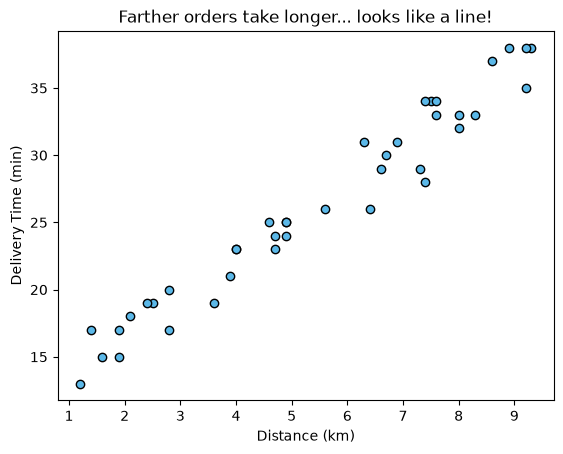

In [9]:
import matplotlib.pyplot as plt
plt.scatter(df.distance_km,df.delivery_time_min,color='#5BB8E8',edgecolor='k')
plt.xlabel("Distance (km)")
plt.ylabel("Delivery Time (min)")
plt.title("Farther orders take longer... looks like a line!")
plt.show()

In [11]:
#pip install scikit-learn

In [12]:
from sklearn.linear_model import LinearRegression
model = LinearRegression()
model.fit(df[['distance_km']],df['delivery_time_min']) # Actual Training

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies the convergence criterion of the underlying solver. `tol` isset as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. `tol` is set as `cond` of:func:`scipy.linalg.lstsq` when fitting on dense training data... versionadded:: 1.7.. versionchanged:: 1.9 Now supported on dense data, interpreted as the `cond` parameter.",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary <n_jobs>` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False
Name,Type,Value
"coef_ coef_: array of shape (n_features, ) or (n_targets, n_features)Estimated coefficients for the linear regression problem.If multiple targets are passed during the fit (y 2D), thisis a 2D array of shape (n_targets, n_features), while if onlyone target is passed, this is a 1D array of length n_features.","ndarray[float64](1,)",[2.82]
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Defined only when `X`has feature names that are all strings... versionadded:: 1.0","ndarray[object](1,)",['distance_km']
"intercept_ intercept_: float or array of shape (n_targets,)Independent term in the linear model. Set to 0.0 if`fit_intercept = False`.",float64,10.94
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`... versionadded:: 0.24,int,1
rank_ rank_: intRank of matrix `X`. Only available when `X` is dense.,int64,np.int64(1)


In [17]:
import warnings
warnings.filterwarnings("ignore")

In [19]:
model.predict([[7],[34]])

array([ 30.67137739, 106.76252444])

In [21]:
model.predict(pd.DataFrame({'distance_km':[7,34]}))

array([ 30.67137739, 106.76252444])

In [24]:
model.coef_ #m

array([2.81819063])

In [25]:
model.intercept_ #b

np.float64(10.944042964016225)

In [27]:
# y = m*x + b
# time = m * distance + b
time = 2.81819063 * 7 + 10.944042964016225
time

30.671377374016224

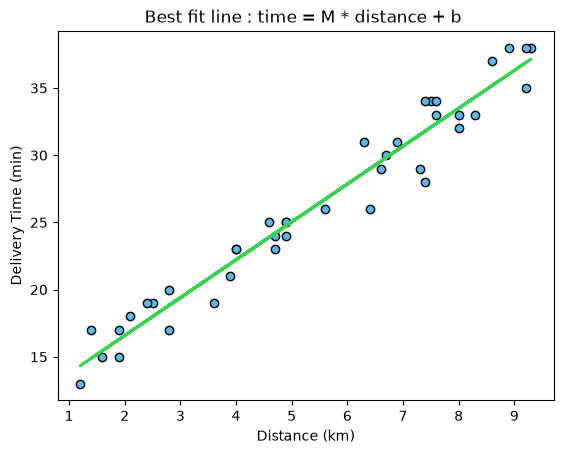

In [29]:
plt.scatter(df.distance_km,df.delivery_time_min,color='#5BB8E8',edgecolor='k')
plt.plot(df.distance_km,model.predict(df[['distance_km']]),color='#39D353',linewidth=2)
plt.xlabel("Distance (km)")
plt.ylabel("Delivery Time (min)")
plt.title("Best fit line : time = M * distance + b ")
plt.show()

In [30]:
df2 = pd.read_csv("delivery_time_multi.csv")
df2.head()

,distance_km,traffic_level,raining,delivery_time_min
0,7.9,5,1,38
1,2.3,10,0,26
2,1.0,2,1,18
3,1.6,6,1,26
4,7.1,6,0,34


In [32]:
model2 = LinearRegression()

In [35]:
features = ['distance_km','traffic_level','raining']
model2.fit(df2[features],df2['delivery_time_min'])

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies the convergence criterion of the underlying solver. `tol` isset as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. `tol` is set as `cond` of:func:`scipy.linalg.lstsq` when fitting on dense training data... versionadded:: 1.7.. versionchanged:: 1.9 Now supported on dense data, interpreted as the `cond` parameter.",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary <n_jobs>` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False
Name,Type,Value
"coef_ coef_: array of shape (n_features, ) or (n_targets, n_features)Estimated coefficients for the linear regression problem.If multiple targets are passed during the fit (y 2D), thisis a 2D array of shape (n_targets, n_features), while if onlyone target is passed, this is a 1D array of length n_features.","ndarray[float64](3,)","[2.66,1.26,3.68]"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Defined only when `X`has feature names that are all strings... versionadded:: 1.0","ndarray[object](3,)","['distance_km','traffic_level','raining']"
"intercept_ intercept_: float or array of shape (n_targets,)Independent term in the linear model. Set to 0.0 if`fit_intercept = False`.",float64,7.474
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`... versionadded:: 0.24,int,3
rank_ rank_: intRank of matrix `X`. Only available when `X` is dense.,int64,np.int64(3)


In [37]:
new_order = pd.DataFrame({'distance_km':[7],'traffic_level':[4],'raining':[0]})
model2.predict(new_order)

array([31.09160235])

In [38]:
model2.coef_

array([2.65512204, 1.25783935, 3.68420245])

In [39]:
model2.intercept_

np.float64(7.474390650840871)

In [40]:
time = 2.65512204 * 7 + 1.25783935 * 4 + 3.68420245 * 0 + 7.474390650840871
time

31.09160233084087